In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("D:\csv\heart.csv")

In [4]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x = df.drop("target",axis=1)
y = df["target"]

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

In [11]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)
dt_pred = dt_model.predict(x_test)
print("Accuracy Score : ",accuracy_score(y_test,dt_pred))
print("Classification Report : \n",classification_report(y_test,dt_pred))
print("Confusion Matrix : \n",confusion_matrix(y_test,dt_pred))

Accuracy Score :  0.7540983606557377
Classification Report : 
               precision    recall  f1-score   support

           0       0.69      0.86      0.77        29
           1       0.84      0.66      0.74        32

    accuracy                           0.75        61
   macro avg       0.77      0.76      0.75        61
weighted avg       0.77      0.75      0.75        61

Confusion Matrix : 
 [[25  4]
 [11 21]]


In [12]:
Dt_model = RandomForestClassifier(n_estimators=200,random_state=42)
Dt_model.fit(x_train,y_train)
Dt_pred = Dt_model.predict(x_test)
print("Accuracy Score : ",accuracy_score(y_test,Dt_pred))
print("Classification Report : \n",classification_report(y_test,Dt_pred))
print("Confusion Matrix : \n",confusion_matrix(y_test,Dt_pred))

Accuracy Score :  0.8360655737704918
Classification Report : 
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61

Confusion Matrix : 
 [[24  5]
 [ 5 27]]


In [13]:
log_model = LogisticRegression(random_state=42)
log_model.fit(x_train,y_train)
log_pred = log_model.predict(x_test)
print("Accuracy Score : ",accuracy_score(y_test,log_pred))
print("Classification Report : \n",classification_report(y_test,log_pred))
print("Confusion Matrix : \n",confusion_matrix(y_test,log_pred))

Accuracy Score :  0.8852459016393442
Classification Report : 
               precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61

Confusion Matrix : 
 [[25  4]
 [ 3 29]]


C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.model_selection import GridSearchCV

In [15]:
param_grid = {
    'n_estimators' : [50,100,200],
    'max_depth' : [None,5,10],
    'min_samples_split' : [2,4,8],
}


In [16]:
grid = GridSearchCV(estimator=Dt_model,param_grid=param_grid,cv=3)
grid.fit(x_train,y_train)
best_rf = grid.best_estimator_
print("Best Parameters : ",grid.best_params_)
y_pred = best_rf.predict(x_test)
print("Accuracy Score : ",accuracy_score(y_test,y_pred))
print("Classification Report : \n",classification_report(y_test,y_pred))

Best Parameters :  {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy Score :  0.8360655737704918
Classification Report : 
               precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
feat_imp = pd.DataFrame({
    'Feature' : x_train.columns,
    'Importance' : best_rf.feature_importances_
}).sort_values(by='Importance',ascending=False)
print(feat_imp)

     Feature  Importance
9    oldpeak    0.128485
7    thalach    0.119725
11        ca    0.115533
2         cp    0.103792
12      thal    0.093300
0        age    0.092811
3   trestbps    0.077537
8      exang    0.075809
4       chol    0.074812
10     slope    0.051058
1        sex    0.035658
6    restecg    0.019782
5        fbs    0.011698


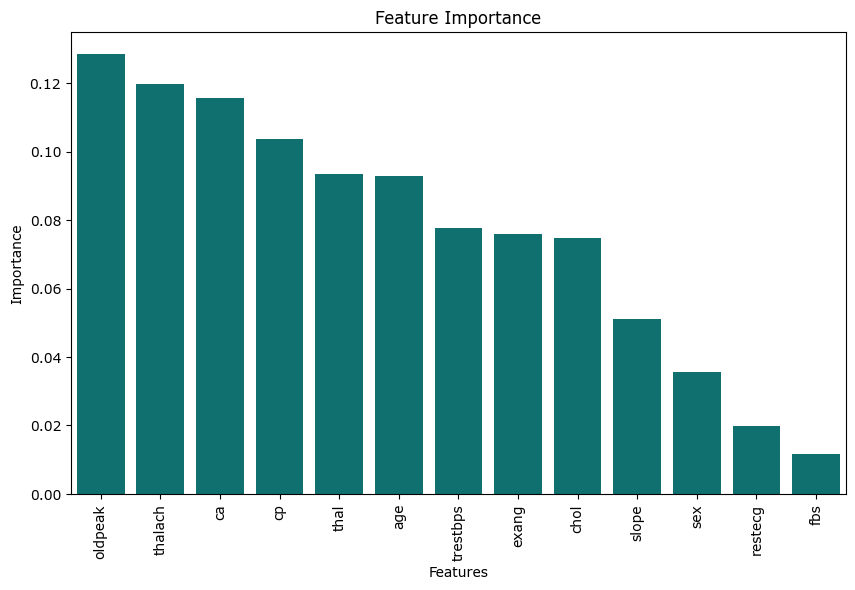

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x='Feature',y='Importance',data=feat_imp, color='teal')
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.show()

In [20]:
acc = pd.DataFrame({
    'Model' : ['Decision Tree','Random Forest','Logistic Regression'],
    'Accuracy' : [accuracy_score(y_test,dt_pred),accuracy_score(y_test,Dt_pred),accuracy_score(y_test,log_pred)]
})

In [21]:
print(acc)

                 Model  Accuracy
0        Decision Tree  0.754098
1        Random Forest  0.836066
2  Logistic Regression  0.885246


In [22]:
!pip install streamlit
!pip install pyngrok



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pickle
from sklearn.linear_model import LogisticRegression

# assume X_train, y_train ready
model = LogisticRegression()
model.fit(x_train, y_train)

# save model
with open("heart_model.pkl", "wb") as f:
    pickle.dump(model, f)


C:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle

with open("heart_model.pkl", "rb") as f:
    model = pickle.load(f)

st.title("Heart Disease Prediction App ❤️")

# Inputs
age = st.number_input("Age", 1, 120, 30)
sex = st.selectbox("Sex", ["Male", "Female"])
cp = st.slider("Chest Pain Type (0-3)", 0, 3, 0)
trestbps = st.number_input("Resting Blood Pressure", 80, 200, 120)
chol = st.number_input("Cholesterol", 100, 400, 200)
fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl", [0,1])
restecg = st.slider("Resting ECG (0-2)", 0, 2, 0)
thalach = st.number_input("Max Heart Rate Achieved", 60, 220, 150)
exang = st.selectbox("Exercise Induced Angina", [0,1])
oldpeak = st.number_input("ST Depression (oldpeak)", 0.0, 6.0, 1.0)
slope = st.slider("Slope of ST Segment (0-2)", 0, 2, 1)
ca = st.slider("Number of Major Vessels (0-3)", 0, 3, 0)
thal = st.slider("Thalassemia (1-3)", 1, 3, 2)

sex = 1 if sex=="Male" else 0

input_df = pd.DataFrame([[age, sex, cp, trestbps, chol, fbs,
                          restecg, thalach, exang, oldpeak,
                          slope, ca, thal]],
                        columns=['age','sex','cp','trestbps','chol','fbs',
                                 'restecg','thalach','exang','oldpeak',
                                 'slope','ca','thal'])

if st.button("Predict Heart Disease"):
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    if prediction == 1:
        st.error(f"⚠️ High Risk! Probability: {probability:.2f}")
    else:
        st.success(f"✅ Low Risk. Probability: {probability:.2f}")


Overwriting app.py


In [ ]:
from pyngrok import ngrok

!streamlit run app.py &  # start app in background
public_url = ngrok.connect(port='8501')
public_url  # click this to open app in browser
